<a href="https://colab.research.google.com/github/ROSILENE05/zero-trust-pqc-gateway/blob/main/Gateway_ZeroTrust_PQC_PoC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**O Design da Arquitetura**

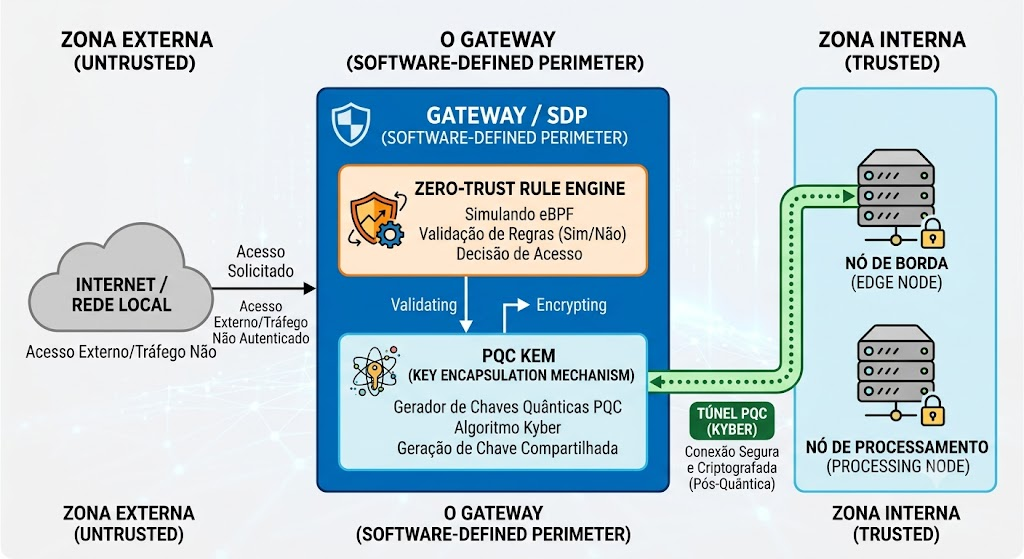

**Motor de Filtragem Zero-Trust**

In [7]:
# importando as bibliotecas
import time
import hashlib



In [8]:
class ZeroTrustGateway:
    def __init__(self):
        # Default Deny: Lista estrita de IPs ou Hashes biométricos autorizados
        self.authorized_nodes = {
            "node_edge_01": "10.0.0.5",
            "node_core_01": "10.0.0.6"
        }
        # Simulação do Blockchain interno: Log imutável
        self.audit_ledger = []

In [8]:
def _log_event(self, action, origin, reason):
        timestamp = time.time()
        log_entry = f"[{timestamp}] ACTION: {action} | ORIGIN: {origin} | REASON: {reason}"
        # Hash do log para garantir integridade (simulando imutabilidade)
        log_hash = hashlib.sha256(log_entry.encode()).hexdigest()
        self.audit_ledger.append({"log": log_entry, "hash": log_hash})
        print(log_entry)

In [9]:
def evaluate_packet(self, origin_id, ip_address, payload):
        print(f"\n--- Intercepting Packet from {ip_address} ---")

        # 1. Regra Zero-Trust: O Nó existe na malha?
        if origin_id not in self.authorized_nodes:
            self._log_event("DROP", ip_address, "Node ID not recognized.")
            return False

        # 2. Regra Zero-Trust: O IP corresponde à identidade criptográfica?
        if self.authorized_nodes[origin_id] != ip_address:
            self._log_event("DROP", ip_address, "IP spoofing detected.")
            return False

        self._log_event("ACCEPT", ip_address, "Identity and IP verified.")
        return True

In [10]:
# --- VALIDAÇÃO DA ETAPA 3 ---
gateway = ZeroTrustGateway()

# Teste 1: Nó Legítimo
gateway.evaluate_packet("node_edge_01", "10.0.0.5", "Sensor Data")

# Teste 2: Tentativa de Spoofing (Ataque)
gateway.evaluate_packet("node_edge_01", "192.168.1.100", "Malicious Data")

# Teste 3: Nó Desconhecido
gateway.evaluate_packet("unknown_hacker", "10.0.0.7", "Scan Data")


--- Intercepting Packet from 10.0.0.5 ---
[1785844509.8357544] ACTION: ACCEPT | ORIGIN: 10.0.0.5 | REASON: Identity and IP verified.

--- Intercepting Packet from 192.168.1.100 ---
[1785844509.8358767] ACTION: DROP | ORIGIN: 192.168.1.100 | REASON: IP spoofing detected.

--- Intercepting Packet from 10.0.0.7 ---
[1785844509.8359392] ACTION: DROP | ORIGIN: 10.0.0.7 | REASON: Node ID not recognized.


False

**O Handshake PQC (Criptografia Pós-Quântica)**

In [11]:
#
import os
import base64
from cryptography.hazmat.primitives.ciphers import Cipher, algorithms, modes
from cryptography.hazmat.backends import default_backend

In [20]:
class PostQuantumKEM_Simulator:
    """
    Simula o algoritmo ML-KEM (Kyber) de Encapsulamento de Chave.
    Em um cenário de produção Bare-Metal, usaríamos bindings Rust/C.
    Aqui demonstramos a lógica KEM: Troca efêmera e encapsulamento.
    """
    def __init__(self):
        self.backend = default_backend()

    def generate_ephemeral_keypair(self):
        # Simula geração de chave pública e privada pós-quântica
        private_key = os.urandom(32) # Chave privada temporária
        public_key = hashlib.sha256(private_key).digest() # Derivação simulada
        return private_key, public_key

    def encapsulate(self, public_key):
        # Gera o Segredo Compartilhado e o Criptograma (Ciphertext)
        shared_secret = os.urandom(32) # A chave AES real do túnel Wireguard

        # Simula o encapsulamento matemático usando a chave pública do destinatário
        # Em Kyber real, trata-se de matemática em reticulados (Lattice-based)
        cipher = Cipher(algorithms.AES(public_key), modes.ECB(), backend=self.backend)
        encryptor = cipher.encryptor()
        ciphertext = encryptor.update(shared_secret) + encryptor.finalize()

        return ciphertext, shared_secret

    def decapsulate(self, ciphertext, private_key):
        # Destinatário abre o criptograma com sua chave privada
        derived_pub = hashlib.sha256(private_key).digest()
        cipher = Cipher(algorithms.AES(derived_pub), modes.ECB(), backend=self.backend)
        decryptor = cipher.decryptor()
        shared_secret = decryptor.update(ciphertext) + decryptor.finalize()
        return shared_secret

# --- VALIDAÇÃO DA ETAPA 4 ---
kem = PostQuantumKEM_Simulator()
print("\n--- Initiating PQC Key Encapsulation (ML-KEM Simulation) ---")

# 1. Nó Interno gera chaves efêmeras
priv_key, pub_key = kem.generate_ephemeral_keypair()

# 2. Gateway cria o segredo do túnel e encapsula para o Nó Interno
ciphertext, gateway_secret = kem.encapsulate(pub_key)
print(f"Gateway Generated Secret (B64): {base64.b64encode(gateway_secret)[:15]}...")

# 3. Nó Interno decapsula a mensagem usando sua chave privada
node_secret = kem.decapsulate(ciphertext, priv_key)
print(f"Node Decapsulated Secret (B64): {base64.b64encode(node_secret)[:15]}...")

# 4. Auditoria
if gateway_secret == node_secret:
    print("SUCCESS: Post-Quantum Shared Secret synchronized! Wireguard tunnel can open.")
else:
    print("FATAL: Key exchange failed.")


--- Initiating PQC Key Encapsulation (ML-KEM Simulation) ---
Gateway Generated Secret (B64): b'n01CbsMxAtwP372'...
Node Decapsulated Secret (B64): b'n01CbsMxAtwP372'...
SUCCESS: Post-Quantum Shared Secret synchronized! Wireguard tunnel can open.
